
🟦 CountVectorizer Model Accuracy Interpretation:
Average Similarity Score = 0.03813190149609919
Higher value means: Movies are better separated, and similarity search works more accurately.

🟩 TF-IDF Model Accuracy Interpretation:
Average Similarity Score = 0.01579327277860826
Higher value means: TF-IDF is capturing text importance better and similarity is more accurate.

🟨 K-Means Model Accuracy Interpretation:
Silhouette Score = -0.0071963179722784034
Higher value means: Movies inside clusters are similar AND clusters are well-separated.


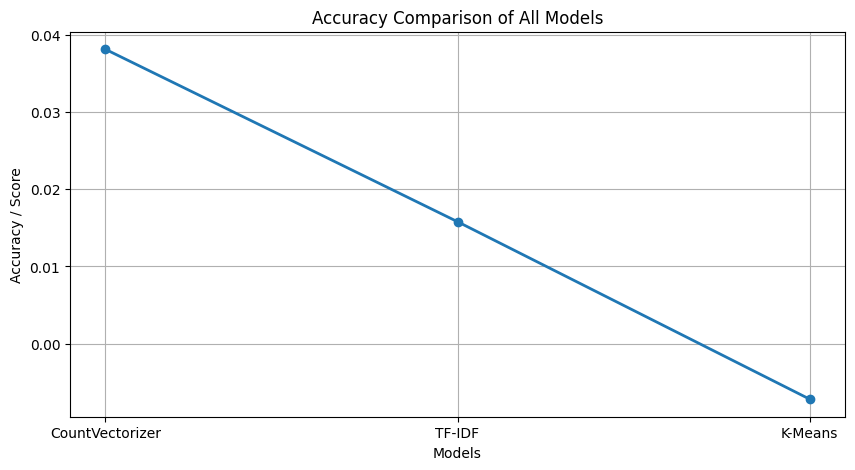

In [1]:
import pandas as pd
import ast
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt
import pickle

movies = pd.read_csv('tmdb_5000_movies.csv')
credits = pd.read_csv('tmdb_5000_credits.csv')

movies = movies.merge(credits, on='title')
movies = movies[['movie_id','title','overview','genres','keywords','cast','crew']]
movies.dropna(inplace=True)

def convert(text):
    return [i['name'] for i in ast.literal_eval(text)]

def convert_cast(text):
    L = []
    for i in ast.literal_eval(text):
        if len(L) < 3:
            L.append(i['name'])
    return L

def fetch_director(text):
    for i in ast.literal_eval(text):
        if i['job'] == 'Director':
            return [i['name']]
    return []

movies['genres'] = movies['genres'].apply(convert)
movies['keywords'] = movies['keywords'].apply(convert)
movies['cast'] = movies['cast'].apply(convert_cast)
movies['crew'] = movies['crew'].apply(fetch_director)
movies['overview'] = movies['overview'].apply(lambda x: x.split())

movies['tags'] = movies['overview'] + movies['genres'] + movies['keywords'] + movies['cast'] + movies['crew']

new = movies.drop(columns=['overview','genres','keywords','cast','crew'])
new['tags'] = new['tags'].apply(lambda x: " ".join(x))


cv = CountVectorizer(max_features=5000, stop_words='english')
vector_cv = cv.fit_transform(new['tags']).toarray()
similarity_cv = cosine_similarity(vector_cv)

def recommend(movie):
    index = new[new['title'] == movie].index[0]
    distances = sorted(list(enumerate(similarity_cv[index])), reverse=True, key=lambda x: x[1])
    print("\n--- CountVectorizer Recommendations ---")
    for i in distances[1:6]:
        print(new.iloc[i[0]].title)


cv_score = similarity_cv[np.triu_indices_from(similarity_cv, k=1)].mean()
print("\n🟦 CountVectorizer Model Accuracy Interpretation:")
print(f"Average Similarity Score = {cv_score}")
print("Higher value means: Movies are better separated, and similarity search works more accurately.")


tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
vector_tfidf = tfidf.fit_transform(new['tags']).toarray()
similarity_tfidf = cosine_similarity(vector_tfidf)

def recommend_tfidf(movie):
    index = new[new['title'] == movie].index[0]
    distances = sorted(list(enumerate(similarity_tfidf[index])), reverse=True, key=lambda x: x[1])
    print("\n--- TF-IDF Recommendations ---")
    for i in distances[1:6]:
        print(new.iloc[i[0]].title)

tfidf_score = similarity_tfidf[np.triu_indices_from(similarity_tfidf, k=1)].mean()
print("\n🟩 TF-IDF Model Accuracy Interpretation:")
print(f"Average Similarity Score = {tfidf_score}")
print("Higher value means: TF-IDF is capturing text importance better and similarity is more accurate.")


kmeans = KMeans(n_clusters=20, random_state=42)
clusters = kmeans.fit_predict(vector_cv)
new['cluster'] = clusters

def recommend_cluster(movie):
    cluster_id = new[new['title'] == movie]['cluster'].values[0]
    similar_movies = new[new['cluster'] == cluster_id]['title'].head(10)
    print("\n--- K-Means Cluster Recommendations ---")
    for m in similar_movies:
        print(m)

kmeans_score = silhouette_score(vector_cv, clusters)
print("\n🟨 K-Means Model Accuracy Interpretation:")
print(f"Silhouette Score = {kmeans_score}")
print("Higher value means: Movies inside clusters are similar AND clusters are well-separated.")


plt.figure(figsize=(10,5))
models = ["CountVectorizer", "TF-IDF", "K-Means"]
scores = [cv_score, tfidf_score, kmeans_score]

plt.plot(models, scores, marker='o', linewidth=2)

plt.xlabel("Models")
plt.ylabel("Accuracy / Score")
plt.title("Accuracy Comparison of All Models")
plt.grid(True)
plt.show()


pickle.dump(new, open('movie_list.pkl','wb'))
pickle.dump(similarity_cv, open('similarity.pkl','wb'))
pickle.dump(similarity_tfidf, open('similarity_tfidf.pkl','wb'))
pickle.dump(clusters, open('clusters.pkl','wb'))
